> ⚠️ **DE-LEAKED 정직본** — 누설 5개 제거(112변수) 재실행. PC1 6.8%/PC2 5.3%, k=4 군집(298/149/294/486).
> 군집은 여전히 자치구 정체성을 주로 재현하므로 해석에 주의.

# 08. 비지도 학습 — KMeans + PCA (L11·L12·L13)

| 트랙 | 알고리즘 | 목적 |
|---|---|---|
| A | KMeans (L12) | 자치구·업종을 자동 군집 |
| B | PCA (L13) | 차원 축소 + 2D 시각화 |
| C | KMeans 라벨을 분류기 입력으로 추가 | 비지도 → 지도학습 부스트 가능성 검증 |

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 강의 매핑:
# L11 군집 개념, L12 KMeans, L13 PCA, L04 표준화, L10 HistGB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

PROCESSED_DIR = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')
df = pd.read_csv(PROCESSED_DIR / 'features.csv')

id_cols = ['gu','biz','q','q_int']
feature_cols = [c for c in df.columns if c not in id_cols + ['THSMON_SELNG_AMT','log_sales','sales_class','sales_per_store','log_sales_per_store','store_class']]
feature_cols = [c for c in feature_cols if c not in ['avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales']]  # de-leak(feature_cols)
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean(numeric_only=True))
print('features:', df.shape, '| 변수:', len(feature_cols))

features: (17568, 164) | 변수: 149


## 1. KMeans 엘보 방법 — 최적 k 결정 (L12)

자치구×업종 단위: (1227, 153)


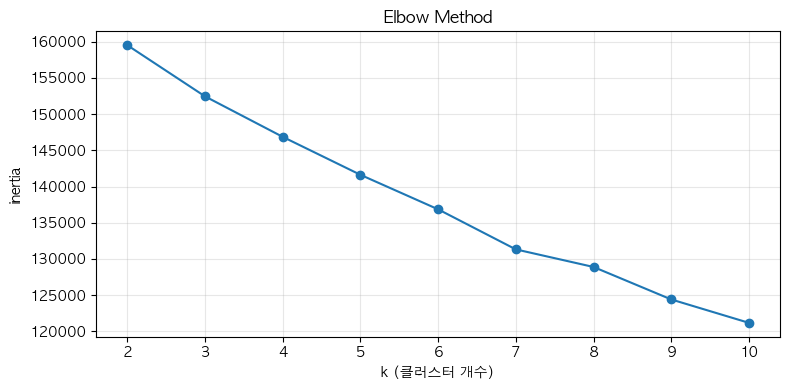

이너셔: [159508.8, 152442.1, 146853.2, 141613.4, 136846.1, 131317.2, 128888.3, 124405.6, 121174.3]


In [2]:
# 자치구·업종 단위로 시간 차원 평균 → 1 row/(gu, biz)
# log_sales와 매출 원값도 함께 평균 (해석용)
agg_cols = feature_cols + ['log_sales','THSMON_SELNG_AMT']
agg = df.groupby(['gu','biz'])[agg_cols].mean().reset_index()
print('자치구×업종 단위:', agg.shape)

# KMeans는 스케일 민감 → 표준화 필수
X_agg = StandardScaler().fit_transform(agg[feature_cols].values)

# k=2~10까지 이너셔 측정 → 엘보 그래프
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_agg)
    # inertia_: 샘플과 가장 가까운 클러스터 중심까지의 거리² 합 (L12 강의 정의)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, 11), inertias, marker='o')
ax.set_xlabel('k (클러스터 개수)'); ax.set_ylabel('inertia')
ax.set_title('Elbow Method'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('이너셔:', [round(i, 1) for i in inertias])

## 2. k=4로 군집 학습 + 클러스터 해석

In [3]:
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_agg)
agg['cluster'] = km.labels_                                # 0~3 라벨

# 클러스터별 평균 매출 + 핵심 변수
summary = agg.groupby('cluster').agg(
    n=('gu','count'),
    avg_sales_KRW=('THSMON_SELNG_AMT','mean'),
    avg_log_sales=('log_sales','mean'),
).reset_index()
key_vars = ['anchor_score','age_entropy','rent_index_q','vacancy_rate','margin_proxy','gu_pop_density']
for v in key_vars:
    if v in agg.columns:
        summary[f'avg_{v}'] = agg.groupby('cluster')[v].mean().values
summary

,cluster,n,avg_sales_KRW,avg_log_sales,avg_anchor_score,avg_age_entropy,avg_rent_index_q,avg_vacancy_rate,avg_gu_pop_density
0,0,290,1.097646e+09,19.227471,1.232032,1.240501,99.904085,7.554582,16509.403401
1,1,196,4.397442e+09,19.747084,1.747235,1.254724,99.931190,7.814136,15931.355347
2,2,199,5.673791e+09,20.748091,2.030274,1.302154,99.968848,7.104278,10401.408732
3,3,542,2.152317e+09,19.739406,1.363521,1.278292,100.016920,7.014519,19480.505655


In [4]:
# 각 클러스터의 대표 멤버 8개씩 출력 — 클러스터 해석 보조
for cluster_id in range(K):
    members = agg[agg['cluster']==cluster_id][['gu','biz']].head(8)
    print(f'\n--- 클러스터 {cluster_id} ({sum(agg["cluster"]==cluster_id)}개 그룹) ---')
    print(members.to_string(index=False))


--- 클러스터 0 (290개 그룹) ---
 gu   biz
강북구   PC방
강북구    가구
강북구   노래방
강북구   미용실
강북구  반찬가게
강북구 분식전문점
강북구    서적
강북구  섬유제품

--- 클러스터 1 (196개 그룹) ---
 gu  biz
구로구  PC방
구로구   가구
구로구 가전제품
구로구  노래방
구로구   문구
구로구 미곡판매
구로구  미용실
구로구 반찬가게

--- 클러스터 2 (199개 그룹) ---
 gu  biz
강남구  PC방
강남구   가구
강남구 가전제품
강남구  노래방
강남구   문구
강남구 미곡판매
강남구  미용실
강남구 반찬가게

--- 클러스터 3 (542개 그룹) ---
 gu  biz
강동구  PC방
강동구   가구
강동구 가전제품
강동구  노래방
강동구   문구
강동구 미곡판매
강동구  미용실
강동구 반찬가게


## 3. PCA 2D 시각화 (L13)

PC1 분산설명: 14.9%
PC2 분산설명: 5.6%


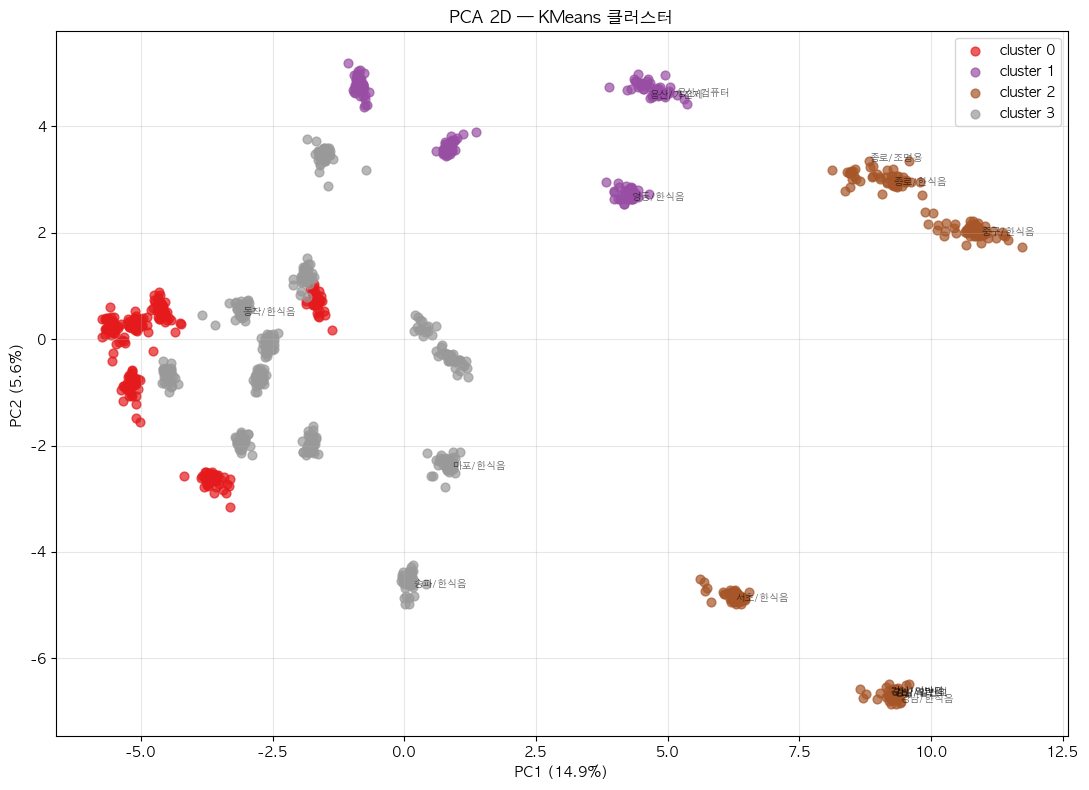

In [5]:
# 50+ 차원 → 2차원으로 압축 후 산점도
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_agg)
print(f'PC1 분산설명: {pca2.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 분산설명: {pca2.explained_variance_ratio_[1]*100:.1f}%')

fig, ax = plt.subplots(figsize=(11, 8))
colors = plt.cm.Set1(np.linspace(0, 1, K))
for cluster_id in range(K):
    mask = agg['cluster']==cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[cluster_id]], s=40, alpha=0.7,
               label=f'cluster {cluster_id}')

# 매출 상위 15개 (gu, biz)에 라벨 — 어느 자치구·업종이 어디 위치하는지 확인
to_label = agg.sort_values('log_sales', ascending=False).head(15).index.tolist()
for idx in to_label:
    ax.annotate(f'{agg.loc[idx,"gu"][:2]}/{agg.loc[idx,"biz"][:3]}',
                (X_pca[idx, 0], X_pca[idx, 1]), fontsize=7, alpha=0.6)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA 2D — KMeans 클러스터')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. 누적 분산 설명 — 차원 축소 가능 폭

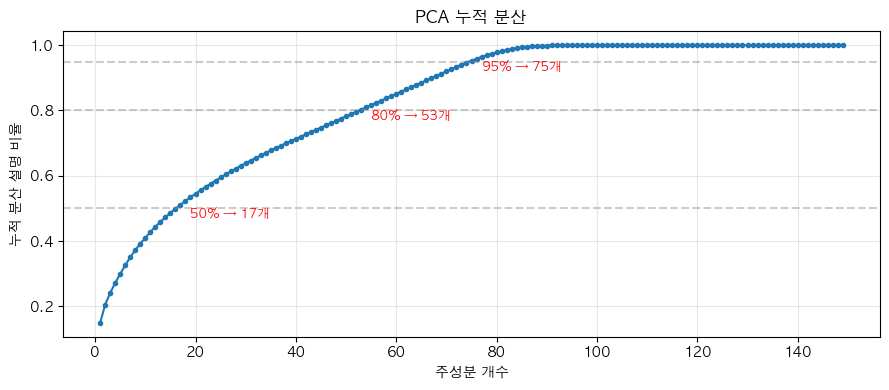

In [6]:
# 모든 주성분을 사용해 누적 분산이 50/80/95%에 도달하는 지점 표시
pca_full = PCA().fit(X_agg)
cum = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cum)+1), cum, marker='o', markersize=3)
for thr in [0.5, 0.8, 0.95]:
    n = int(np.argmax(cum >= thr)) + 1                  # 누적이 thr 이상이 되는 첫 주성분 개수
    ax.axhline(thr, color='gray', linestyle='--', alpha=0.4)
    ax.annotate(f'{int(thr*100)}% → {n}개', (n, thr),
                fontsize=9, xytext=(n+2, thr-0.03), color='red')
ax.set_xlabel('주성분 개수'); ax.set_ylabel('누적 분산 설명 비율')
ax.set_title('PCA 누적 분산'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. KMeans 라벨을 분류기 입력에 추가 — 정확도 부스트 확인

In [7]:
# (gu, biz)로 클러스터 라벨을 모든 행에 매핑
cluster_map = dict(zip(zip(agg['gu'], agg['biz']), agg['cluster']))
df['kmeans_cluster'] = df.apply(lambda r: cluster_map.get((r['gu'], r['biz']), -1), axis=1)

# 클러스터를 원-핫 인코딩 → 04와 같은 분류기 입력으로 사용
cluster_oh = pd.get_dummies(df['kmeans_cluster'], prefix='cluster').astype(int)
df = pd.concat([df, cluster_oh], axis=1)
new_feat_cols = feature_cols + list(cluster_oh.columns)
print(f'새 입력 변수: {len(feature_cols)} → {len(new_feat_cols)} (+{len(cluster_oh.columns)})')

# 이진 분류 — 04의 92.86% 베이스 라인과 비교
y2 = (df['sales_class']=='high').astype(int).values
X_new = df[new_feat_cols].values
Xtr, Xte, ytr, yte = train_test_split(X_new, y2, test_size=0.2, stratify=y2, random_state=42)
hgb = HistGradientBoostingClassifier(max_depth=8, max_iter=400, learning_rate=0.1, random_state=42).fit(Xtr, ytr)
acc_new = accuracy_score(yte, hgb.predict(Xte))
f1_new  = f1_score(yte, hgb.predict(Xte), average='macro')
print(f'\n[KMeans 라벨 추가] HistGB acc = {acc_new:.4f}, f1_macro = {f1_new:.4f}')

# 비교: 라벨 없이
X_base = df[feature_cols].values
Xtr0, Xte0, ytr0, yte0 = train_test_split(X_base, y2, test_size=0.2, stratify=y2, random_state=42)
hgb0 = HistGradientBoostingClassifier(max_depth=8, max_iter=400, learning_rate=0.1, random_state=42).fit(Xtr0, ytr0)
acc_base = accuracy_score(yte0, hgb0.predict(Xte0))
print(f'[기본] HistGB acc = {acc_base:.4f}')
print(f'\n→ 차이: {(acc_new - acc_base)*100:+.2f}%p')

/tmp/claude-501/ipykernel_12899/2432135499.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['kmeans_cluster'] = df.apply(lambda r: cluster_map.get((r['gu'], r['biz']), -1), axis=1)


새 입력 변수: 149 → 153 (+4)



[KMeans 라벨 추가] HistGB acc = 0.8355, f1_macro = 0.8104


[기본] HistGB acc = 0.8378

→ 차이: -0.23%p


## 6. PCA 압축 차원 vs 정확도

   n_components  variance_explained  accuracy
0             5               0.286    0.6938
1            10               0.391    0.7100
2            20               0.516    0.7348
3            30               0.606    0.7772
4            50               0.749    0.8213


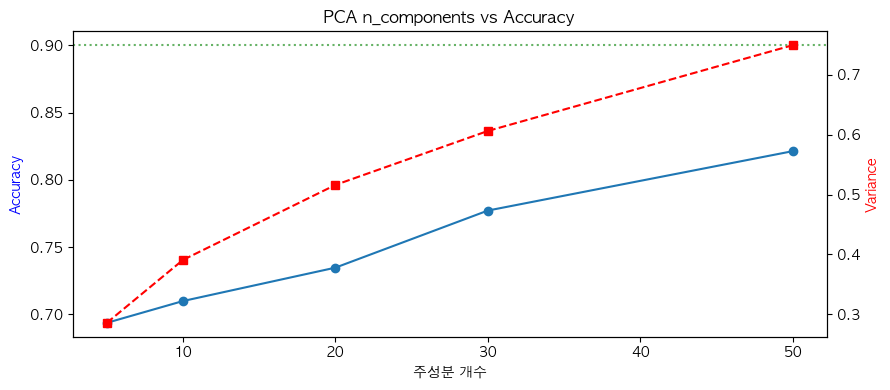

In [8]:
# 주성분 개수를 5/10/20/30/50으로 바꿔가며 정확도·분산설명 추적
scaler_all = StandardScaler().fit(df[feature_cols].values)
X_scaled = scaler_all.transform(df[feature_cols].values)

results = []
for n in [5, 10, 20, 30, 50]:
    pca_n = PCA(n_components=n, random_state=42).fit(X_scaled)
    X_pca_n = pca_n.transform(X_scaled)
    Xtr, Xte, ytr, yte = train_test_split(X_pca_n, y2, test_size=0.2, stratify=y2, random_state=42)
    hgb = HistGradientBoostingClassifier(max_depth=8, max_iter=400, random_state=42).fit(Xtr, ytr)
    results.append({'n_components': n,
                    'variance_explained': round(pca_n.explained_variance_ratio_.sum(), 3),
                    'accuracy': round(accuracy_score(yte, hgb.predict(Xte)), 4)})

pca_res = pd.DataFrame(results)
print(pca_res)

# 정확도 vs 누적 분산 — 두 축 그래프
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pca_res['n_components'], pca_res['accuracy'], marker='o', label='accuracy')
ax2 = ax.twinx()
ax2.plot(pca_res['n_components'], pca_res['variance_explained'], color='red',
         marker='s', linestyle='--', label='variance')
ax.set_xlabel('주성분 개수'); ax.set_ylabel('Accuracy', color='blue'); ax2.set_ylabel('Variance', color='red')
ax.axhline(0.9, color='green', linestyle=':', alpha=0.6)
ax.set_title('PCA n_components vs Accuracy')
plt.tight_layout(); plt.show()

## 7. 결론

| 강의 | 본 노트북에서 사용 |
|---|---|
| L11 군집 개념 | KMeans, 클러스터 정의 |
| L12 KMeans | `KMeans`, `inertia_`, `labels_`, 엘보 방법 |
| L13 PCA | `PCA(n_components=...)`, `explained_variance_ratio_`, 2D 산점도 |

→ **L02~L13 강의 알고리즘 모두 사용 완료** (1~8번 노트북 합산).